In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os

# CPU fallback (if GPU is not available)
if 'JAX_PLATFORMS' not in os.environ:
    try:
        from jax import devices
        if not any(d.platform == 'gpu' for d in devices()):
            os.environ['JAX_PLATFORMS'] = 'cpu'
    except Exception:
        os.environ['JAX_PLATFORMS'] = 'cpu'

# Import necessary librariesimport jax.nnx as nnx
import jax
import jax.numpy as jnp
import jax.random as random
import optax
from tqdm import tqdm
from utils import DataLoader, MLP, train_step, evaluation_step, MLP_trial
from flax import nnx
from flax.nnx.training.metrics import MultiMetric, Average
import optax
import matplotlib.pyplot as plt
from utils import variables_generator

In [12]:
f_to_learn = lambda mu, l, k, x: jnp.exp(l*x) + jnp.sin(mu*2*jnp.pi*x) + k*x

# DATASET GENERATION
key = random.key(0)
mu_domain = (0, 1)
l_domain = (0, 1)
k_domain = (-2, 2)
x_domain = (-1, 1)
N = 5000
mu, l, k, x = variables_generator(N = N, domains = [mu_domain, l_domain, k_domain, x_domain], key = key)
y = f_to_learn(mu, l, k, x)
X = jnp.stack([mu, l, k, x], axis=1)

# DATASET SPLIT AND DATALOADERS CREATION
split_idx = int(N * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
train_dataloader = DataLoader(X_train, y_train, batch_size=8, shuffle=True)
test_dataloader = DataLoader(X_test, y_test, batch_size=8, shuffle=False)

In [13]:
# FOR NOW: TARGET NETWORK WITH KNOWN FIXED NUMBER OF PARAMETERS
num_params = 97
hypernetwork = MLP_trial(input_dim=3, output_dim=num_params, hidden_dim1=32, hidden_dim2=128, num_hidden_layers1=2, num_hidden_layers2=1, rngs=nnx.Rngs(0))

# TRAINING AND EVALUATION
optimizer = nnx.Optimizer(hypernetwork, optax.adam(learning_rate=1e-5))
training_metrics = MultiMetric(MSE=Average(argname='loss'), RRMSE=Average(argname='rrmse'))
test_metrics = MultiMetric(MSE=Average(argname='loss'), RRMSE=Average(argname='rrmse'))
training_loss_history = []
test_loss_history = []
epochs = 400
pbar = tqdm(range(epochs))
for epoch in pbar:
    pbar.set_description(f"Epoch {epoch+1}")
    training_metrics.reset()
    test_metrics.reset()
    for data, label in train_dataloader:
        hyperparams = data[:, :-1] # mu, l, k
        x = data[:, -1:] # x
        loss_step, rrmse_step = train_step(hypernetwork, MLP, hyperparams, x, label, optimizer, x.shape[0])
        training_metrics.update(loss=loss_step.item(), rrmse=rrmse_step.item())
    for data, label in test_dataloader:
        hyperparams = data[:, :-1]
        x = data[:, -1:]
        loss_step, rrmse_step = evaluation_step(hypernetwork, MLP, hyperparams, x, label, x.shape[0])
        test_metrics.update(loss=loss_step.item(), rrmse=rrmse_step.item())
    pbar.set_postfix({"training MSE": training_metrics.compute()['MSE'].item(), "training RRMSE": training_metrics.compute()['RRMSE'].item(), "test MSE": test_metrics.compute()['MSE'].item(), "test RRMSE": test_metrics.compute()['RRMSE'].item()})
    training_loss_history.append(training_metrics.compute()['MSE'].item())
    test_loss_history.append(test_metrics.compute()['MSE'].item())

Epoch 400: 100%|██████████| 400/400 [12:31<00:00,  1.88s/it, training MSE=0.0107, training RRMSE=0.094, test MSE=0.0144, test RRMSE=0.11]  


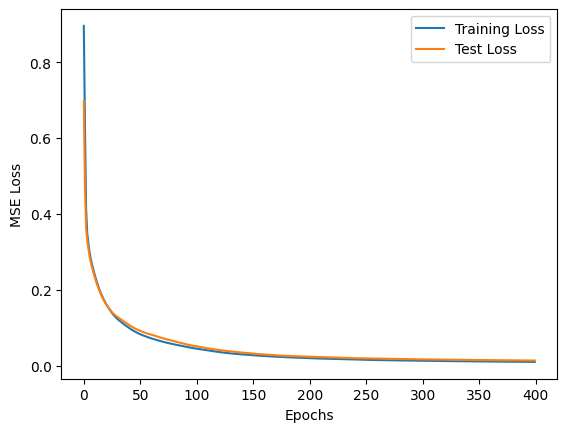

In [19]:
plt.plot(range(epochs), training_loss_history, label='Training Loss')
plt.plot(range(epochs), test_loss_history, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [15]:
# PLOTTING RESULTS ON SOME EXAMPLES
N_example = 4
key_example = random.key(1)  # DON'T PUT 0 TO AVOID DATA LEAKAGE
mu_example, l_example, k_example = variables_generator(N = N_example, domains = [mu_domain, l_domain, k_domain], key = key_example)

example_hypervars = jnp.stack([mu_example, l_example, k_example], axis=1)
particular_hypervars= jnp.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
example_hypervars = jnp.vstack([example_hypervars, particular_hypervars]) 

x_vector = jnp.linspace(-1, 1, 101)
x_vector = x_vector[:,None]

In [16]:
plots_data = []

for hypervars in example_hypervars:
    w = hypernetwork(hypervars)  # get the weights from the hypernetwork
    targetnetwork = MLP(input_dim=1, output_dim=1, hidden_dim=8, num_hidden_layers=2, rngs=nnx.Rngs(0))
    parameters = w.squeeze()

    _, state = nnx.split(targetnetwork)  # assign parameters to the target network
    flat_state = nnx.to_flat_state(state)
    i = 0
    for key, param in flat_state:
        param_size = param.value.size
        param_values = parameters[i:i + param_size]
        param.value = param_values.reshape(param.value.shape)
        i += param_size
    nnx.update(targetnetwork, state)

    mu, l, k = hypervars
    y_pred = targetnetwork(x_vector)  # predicted function values
    y_vector = jnp.array([f_to_learn(mu, l, k, x) for x in x_vector])  # true function values
    
    plots_data.append({ #store data for plotting
        'x': x_vector,
        'y_pred': y_pred,
        'y_true': y_vector,
        'params': (mu, l, k)
    })

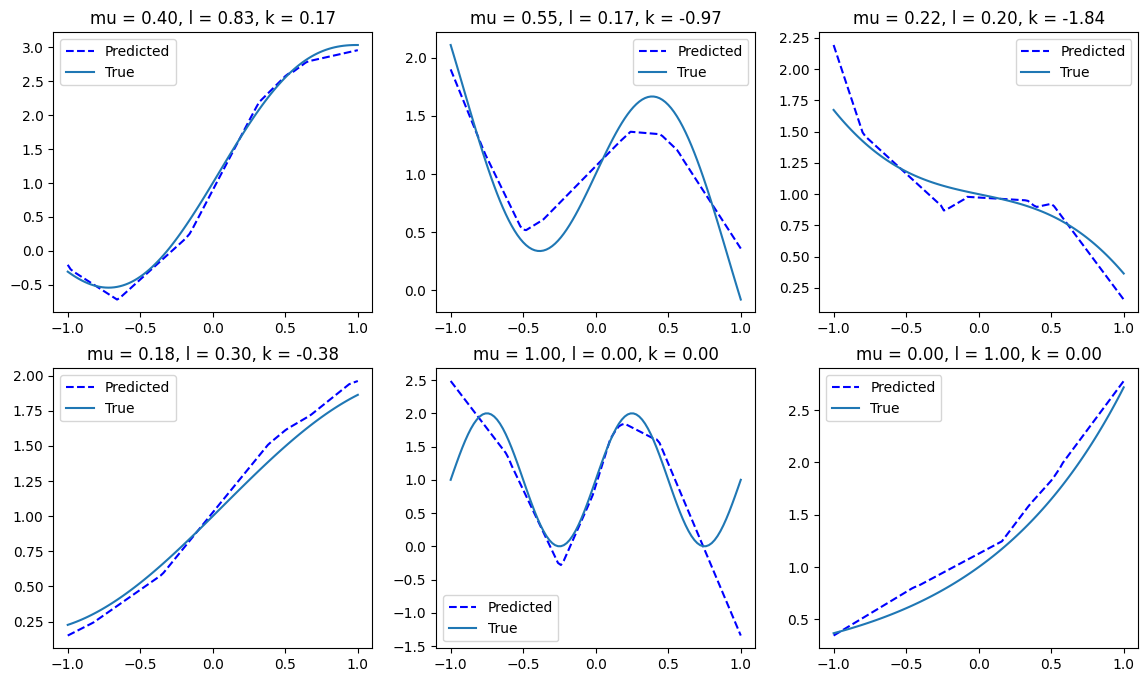

In [17]:
num_cols = 3
fig, ax = plt.subplots(2,num_cols, figsize=(14, 8))
for i, data in enumerate(plots_data[0:6]):
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_pred'], '--b')
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_true'])
    ax[i//num_cols, i%num_cols].legend(['Predicted', 'True'])
    ax[i//num_cols, i%num_cols].set_title(f'mu = {data["params"][0]:.2f}, l = {data["params"][1]:.2f}, k = {data["params"][2]:.2f}')
plt.show()